# TCGA Lung Adenocarcinoma — Exploratory Data Analysis

This notebook explores the clinical and genomic landscape of the TCGA Lung 
Adenocarcinoma (LUAD) cohort (PanCancer Atlas, n=566).

**Question**: Do mutation profiles influence survival outcomes 
beyond tumour stage in lung adenocarcinoma?

**Data source**: cBioPortal — Lung Adenocarcinoma (TCGA, PanCancer Atlas)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
clinical = pd.read_csv('../data/data_clinical_patient.txt', sep='\t', skiprows=4)
mutations = pd.read_csv('../data/data_mutations.txt', sep='\t', low_memory=False)

print("Clinical data shape:", clinical.shape)
print("Mutations data shape:", mutations.shape)
print("\nClinical columns:", clinical.columns.tolist()[:10])

Clinical data shape: (566, 38)
Mutations data shape: (225653, 114)

Clinical columns: ['PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH']


## 1. Patient demographics

We first examine the basic characteristics of the cohort: age distribution, 
sex ratio, and tumour stage breakdown.

=== SURVIVAL DATA ===
     PATIENT_ID   AGE     SEX AJCC_PATHOLOGIC_TUMOR_STAGE   OS_STATUS  \
0  TCGA-05-4244  70.0    Male                    STAGE IV    0:LIVING   
1  TCGA-05-4249  67.0    Male                    STAGE IB    0:LIVING   
2  TCGA-05-4250  79.0  Female                  STAGE IIIA  1:DECEASED   
3  TCGA-05-4382  68.0    Male                    STAGE IB    0:LIVING   
4  TCGA-05-4384  66.0    Male                  STAGE IIIA    0:LIVING   
5  TCGA-05-4389  70.0    Male                    STAGE IA    0:LIVING   
6  TCGA-05-4390  58.0  Female                    STAGE IB    0:LIVING   
7  TCGA-05-4395  76.0    Male                  STAGE IIIB  1:DECEASED   
8  TCGA-05-4396  76.0    Male                  STAGE IIIB  1:DECEASED   
9  TCGA-05-4397  65.0    Male                   STAGE IIB  1:DECEASED   

   OS_MONTHS  
0   0.000000  
1  50.070684  
2   3.978039  
3  19.955946  
4  14.005326  
5  45.007726  
6  37.018772  
7   0.000000  
8   9.961535  
9  24.032613  

=== MISS

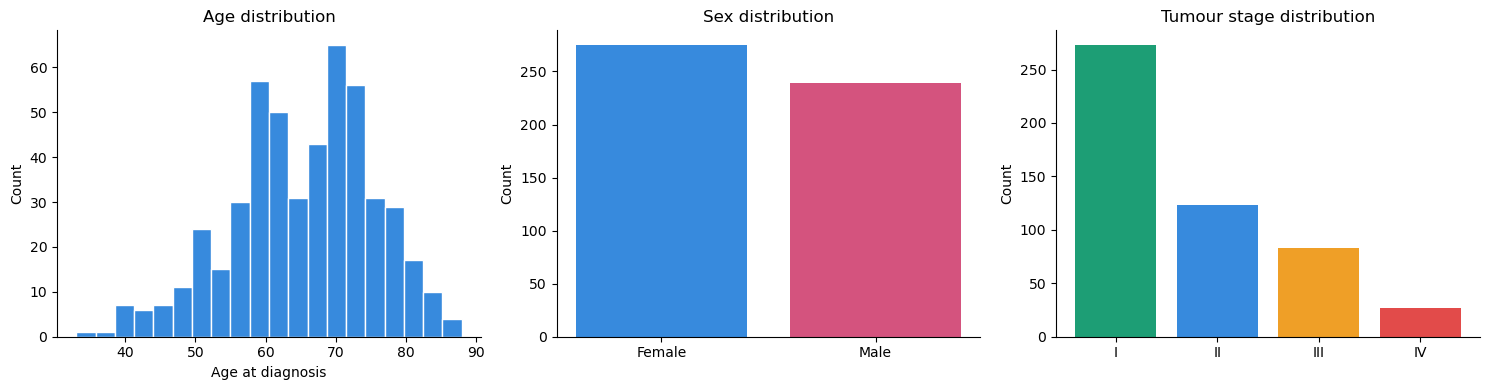

In [28]:
# Basic overview
print("=== SURVIVAL DATA ===")
print(clinical[['PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'OS_STATUS', 'OS_MONTHS']].head(10))

print("\n=== MISSING VALUES ===")
print(clinical.isnull().sum()[clinical.isnull().sum() > 0])

print("\n=== SURVIVAL STATUS ===")
print(clinical['OS_STATUS'].value_counts())

print("=== Tumour stage ===")
print(clinical['STAGE_SIMPLE'].value_counts().reindex(['I','II','III','IV']))
print(f"\nTotal patients with stage data: {clinical['STAGE_SIMPLE'].notna().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(clinical['AGE'].dropna(), bins=20, color='#378ADD', edgecolor='white')
axes[0].set_xlabel('Age at diagnosis')
axes[0].set_ylabel('Count')
axes[0].set_title('Age distribution')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Sex ratio
sex_counts = clinical['SEX'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['#378ADD', '#D4537E'])
axes[1].set_title('Sex distribution')
axes[1].set_ylabel('Count')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Tumour stage
stage_map = {
    'STAGE IA': 'I', 'STAGE IB': 'I',
    'STAGE IIA': 'II', 'STAGE IIB': 'II',
    'STAGE IIIA': 'III', 'STAGE IIIB': 'III',
    'STAGE IV': 'IV'
}
clinical['STAGE_SIMPLE'] = clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].map(stage_map)
stage_counts = clinical['STAGE_SIMPLE'].value_counts().reindex(['I','II','III','IV'])
colors_stage = ['#1D9E75', '#378ADD', '#EF9F27', '#E24B4A']
axes[2].bar(stage_counts.index, stage_counts.values, color=colors_stage)
axes[2].set_title('Tumour stage distribution')
axes[2].set_ylabel('Count')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/demographics.png', dpi=150, bbox_inches='tight')
plt.show()

The cohort is predominantly Stage I (n=267, 47%), reflecting the TCGA sampling bias toward resectable tumours. Stage IV is underrepresented (n=26) compared to real-world incidence where ~50% of LUAD patients present at Stage IV. This is an important limitation to keep in mind when interpreting survival analyses.

## 2. Survival overview

We examine the overall survival distribution and missing data patterns 
before proceeding to formal survival analysis.

In [29]:
clinical['OS_EVENT'] = clinical['OS_STATUS'].apply(
    lambda x: 1 if x == '1:DECEASED' else 0
)

print("=== Survival status ===")
print(clinical['OS_STATUS'].value_counts())
print(f"\nMortality rate: {clinical['OS_EVENT'].mean():.1%}")
print(f"\nMedian follow-up: {clinical['OS_MONTHS'].median():.1f} months")
print(f"Max follow-up: {clinical['OS_MONTHS'].max():.1f} months")

print("\n=== Missing values in key variables ===")
key_vars = ['AGE', 'SEX', 'STAGE_SIMPLE', 'OS_MONTHS', 'OS_STATUS']
print(clinical[key_vars].isnull().sum())

=== Survival status ===
OS_STATUS
0:LIVING      328
1:DECEASED    186
Name: count, dtype: int64

Mortality rate: 32.9%

Median follow-up: 21.5 months
Max follow-up: 238.3 months

=== Missing values in key variables ===
AGE             71
SEX             52
STAGE_SIMPLE    60
OS_MONTHS       61
OS_STATUS       52
dtype: int64


## 3. Mutation landscape

We explore the somatic mutation burden across the cohort and identify the most frequently mutated genes.

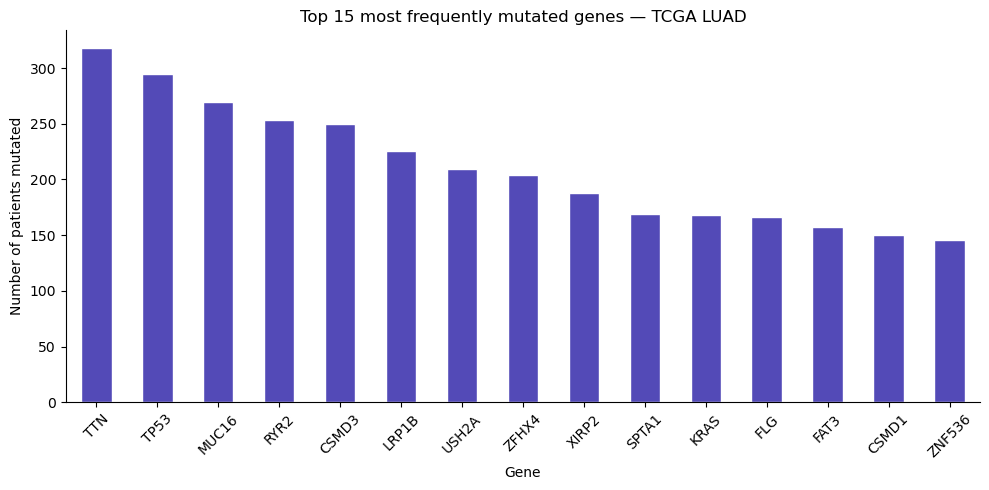

KRAS: 168 patients (29.7%)
STK11: 77 patients (13.6%)
KEAP1: 104 patients (18.4%)


In [34]:
# Top 15 mutated genes
top_genes = (mutations.groupby('Hugo_Symbol')['Tumor_Sample_Barcode']
             .nunique()
             .sort_values(ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
top_genes.plot(kind='bar', ax=ax, color='#534AB7', edgecolor='white')
ax.set_xlabel('Gene')
ax.set_ylabel('Number of patients mutated')
ax.set_title('Top 15 most frequently mutated genes — TCGA LUAD')
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/top_mutated_genes.png', dpi=150, bbox_inches='tight')
plt.show()

# Compter directement depuis le fichier mutations
for gene in ['KRAS', 'STK11', 'KEAP1']:
    n_patients = mutations[mutations['Hugo_Symbol'] == gene]['Tumor_Sample_Barcode'].nunique()
    print(f"{gene}: {n_patients} patients ({n_patients/566:.1%})")

TTN appears as the most frequently mutated gene (n≈316), but this is a well-documented artefact: TTN encodes the largest human protein and accumulates passenger mutations proportional to gene length, not due to selective pressure. It is not considered an oncogenic driver.

TP53 (n≈293) and KRAS (n≈168, ~30%) are the true driver genes of interest. STK11 and KEAP1, though less frequent, define aggressive KRAS co-mutation subtypes and will be the focus of notebook 02.

## 4. Survival overview

Before formal survival analysis, we examine the raw distribution of follow-up times and the overall mortality rate in the cohort.
This gives us a sense of the data quality and censoring pattern.

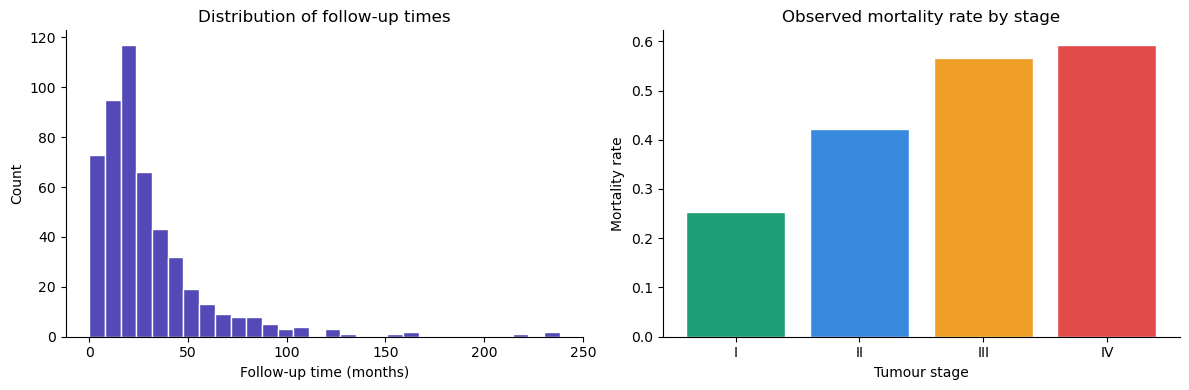

=== Survival summary ===
Total patients: 566
Deceased: 186 (32.9%)
Censored (still alive): 380
Median follow-up: 21.5 months

=== Stage breakdown ===
STAGE_SIMPLE
I      273
II     123
III     83
IV      27
Name: count, dtype: int64


In [35]:
clinical['OS_EVENT'] = clinical['OS_STATUS'].apply(
    lambda x: 1 if x == '1:DECEASED' else 0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of follow-up times
axes[0].hist(clinical['OS_MONTHS'].dropna(), bins=30, 
             color='#534AB7', edgecolor='white')
axes[0].set_xlabel('Follow-up time (months)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of follow-up times')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Mortality by stage
mortality_by_stage = (clinical.groupby('STAGE_SIMPLE')['OS_EVENT']
                      .agg(['sum', 'count'])
                      .reindex(['I','II','III','IV']))
mortality_by_stage['rate'] = mortality_by_stage['sum'] / mortality_by_stage['count']

colors_stage = ['#1D9E75', '#378ADD', '#EF9F27', '#E24B4A']
axes[1].bar(mortality_by_stage.index, mortality_by_stage['rate'], 
            color=colors_stage, edgecolor='white')
axes[1].set_xlabel('Tumour stage')
axes[1].set_ylabel('Mortality rate')
axes[1].set_title('Observed mortality rate by stage')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/survival_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Survival summary ===")
print(f"Total patients: {len(clinical)}")
print(f"Deceased: {clinical['OS_EVENT'].sum()} ({clinical['OS_EVENT'].mean():.1%})")
print(f"Censored (still alive): {(clinical['OS_EVENT']==0).sum()}")
print(f"Median follow-up: {clinical['OS_MONTHS'].median():.1f} months")
print(f"\n=== Stage breakdown ===")
print(clinical['STAGE_SIMPLE'].value_counts().reindex(['I','II','III','IV']))

Two key observations:

**Follow-up distribution**: The right-skewed distribution reflects the 
natural follow-up pattern. Many patients have short follow-up (either 
early death or recent enrollment), with a long tail of long-term survivors. 
This heterogeneity in follow-up time is exactly why Kaplan-Meier is needed 
rather than simple mortality counts.

**Mortality rate by stage**: As expected, mortality increases with stage. 
However, even Stage I patients show non-negligible mortality (~25%), 
reflecting the aggressive biology of LUAD even in early-stage disease. 
Stage IV mortality approaches 60% despite the small sample size (n=26).

**Why this matters**: These raw mortality rates are *not* survival curves. They don't account for follow-up time or censoring. A patient who died at 
2 months and one who died at 200 months both count as "1" here. 
Kaplan-Meier in notebook 02 will give us the proper time-adjusted picture.

## 5. KRAS, STK11, KEAP1 — mutation prevalence

Before survival analysis, we verify the prevalence of our three genes 
of interest in this cohort.

**Why these three genes?**

- **KRAS**: The most common oncogenic driver in LUAD (~30%). 
  Activating mutations (mainly G12C, G12V) constitutively activate 
  the RAS-MAPK proliferation pathway. Historically "undruggable",
  the first targeted therapy (sotorasib) was only approved in 2021.

- **STK11 (LKB1)**: A tumour suppressor. Co-mutation with KRAS defines 
  a subtype with highly immunosuppressive tumour microenvironment, 
  poor response to PD-1/PD-L1 immunotherapy, and worse prognosis.

- **KEAP1**: Regulates NRF2 oxidative stress pathway. KEAP1 loss + KRAS 
  mutation creates metabolic vulnerabilities. Also associated with 
  immunotherapy resistance and poor prognosis.

The clinical stakes: ~50% of advanced LUAD patients receive immunotherapy 
as first-line treatment. Identifying KRAS+STK11 or KRAS+KEAP1 patients 
*before* treatment could avoid ineffective therapy and guide alternative 
strategies.

In [37]:
# Extract mutation status for each patient
def get_mutated_patients(mutations_df, gene):
    mutated = mutations_df[mutations_df['Hugo_Symbol'] == gene]['Tumor_Sample_Barcode'].unique()
    # TCGA barcodes: first 12 characters = patient ID
    return set([b[:12] for b in mutated])

kras_patients = get_mutated_patients(mutations, 'KRAS')
stk11_patients = get_mutated_patients(mutations, 'STK11')
keap1_patients = get_mutated_patients(mutations, 'KEAP1')

clinical['KRAS_MUT'] = clinical['PATIENT_ID'].isin(kras_patients).astype(int)
clinical['STK11_MUT'] = clinical['PATIENT_ID'].isin(stk11_patients).astype(int)
clinical['KEAP1_MUT'] = clinical['PATIENT_ID'].isin(keap1_patients).astype(int)

n = len(clinical)
print("=== Mutation prevalence ===")
print(f"KRAS:  {clinical['KRAS_MUT'].sum()} patients ({clinical['KRAS_MUT'].mean():.1%})")
print(f"STK11: {clinical['STK11_MUT'].sum()} patients ({clinical['STK11_MUT'].mean():.1%})")
print(f"KEAP1: {clinical['KEAP1_MUT'].sum()} patients ({clinical['KEAP1_MUT'].mean():.1%})")

print("\n=== Co-mutation with KRAS ===")
kras_stk11 = ((clinical['KRAS_MUT']==1) & (clinical['STK11_MUT']==1)).sum()
kras_keap1 = ((clinical['KRAS_MUT']==1) & (clinical['KEAP1_MUT']==1)).sum()
print(f"KRAS + STK11: {kras_stk11} patients")
print(f"KRAS + KEAP1: {kras_keap1} patients")

=== Mutation prevalence ===
KRAS:  168 patients (29.7%)
STK11: 77 patients (13.6%)
KEAP1: 104 patients (18.4%)

=== Co-mutation with KRAS ===
KRAS + STK11: 39 patients
KRAS + KEAP1: 36 patients


KRAS is mutated in 168 patients (29.7%), consistent with published LUAD 
genomics. STK11 (13.6%) and KEAP1 (18.4%) are less frequent but clinically 
critical co-alteration partners.

Notably, 39 patients carry both KRAS and STK11 mutations (~23% of KRAS-mutant 
tumours), and 36 carry KRAS+KEAP1 (~21%). These co-mutation groups are large 
enough for meaningful survival subgroup analysis in notebook 02.

## Summary — key findings from EDA

| Variable | Finding |
|----------|---------|
| Cohort size | 566 patients, 493 with complete survival data |
| Stage distribution | 47% Stage I — TCGA sampling bias toward resectable tumours |
| Overall mortality | ~33% deceased in cohort |
| Median follow-up | ~21.5 months |
| KRAS mutation rate | ~30% — consistent with published LUAD genomics |
| KRAS+STK11 | ~39 patients — aggressive subtype, poor immunotherapy response |
| KRAS+KEAP1 | ~36 patients — metabolic vulnerability subtype |

**Next**: Notebook 02 will formally test whether these mutation profiles 
significantly impact survival using Kaplan-Meier, log-rank tests, 
and multivariable Cox regression.